# Grouping Feature Ablation: Primary-Only ranking

This notebook reads `experiment_metric_summary/grouping_feature_ablation_primary_only_sorted.csv` and compares fixed grouping, feature-set ablations, and soft-router runs.

Sorting rule: lower `primary_rank` is better.

In [1]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 140)

repo_dir = Path.cwd()
if repo_dir.name == "notebooks":
    repo_dir = repo_dir.parent

csv_path = repo_dir / "experiment_metric_summary" / "grouping_feature_ablation_primary_only_sorted.csv"
df = pd.read_csv(csv_path)

for col in ["primary_rank", "overall_rank"]:
    if col in df.columns:
        df[col] = df[col].astype(int)

display(Markdown(f"Loaded `{csv_path}` with **{len(df)}** rows."))
display(Markdown("Columns: `" + "`, `".join(df.columns) + "`"))

Loaded `C:\Users\16199\Desktop\RL\annex96_common_exercise_1\experiment_metric_summary\grouping_feature_ablation_primary_only_sorted.csv` with **38** rows.

Columns: `primary_rank`, `primary_rank_score`, `architecture`, `grouping_method_short`, `grouping_feature_set_short`, `feature_group`, `seed`, `experiment`, `primary_load_cv_rmse_pct`, `primary_load_nmbe_pct`, `primary_abs_nmbe_pct`, `primary_comfort_exceedance_pct`, `primary_comfort_exceedance_hours_total`, `primary_comfort_exceedance_hours_mean`, `primary_comfort_exceedance_hours_max`, `test_reward_sum`, `wandb_run_id`

## Main table

Includes compact fixed grouping, previous larger/full grouping, and dynamic soft-router results.

In [2]:
preferred_cols = [
    "primary_rank",
    "primary_rank_score",
    "overall_rank",
    "architecture",
    "grouping_method_short",
    "grouping_feature_set_short",
    "feature_group",
    "primary_load_cv_rmse_pct",
    "primary_abs_nmbe_pct",
    "primary_comfort_exceedance_pct",
    "test_reward_sum",
    "experiment",
]
display_cols = [col for col in preferred_cols if col in df.columns]
table_df = df.sort_values(["primary_rank", "primary_rank_score"])[display_cols]

metric_cols = [
    col for col in [
        "primary_rank",
        "primary_rank_score",
        "primary_load_cv_rmse_pct",
        "primary_abs_nmbe_pct",
        "primary_comfort_exceedance_pct",
    ] if col in table_df.columns
]

display(
    table_df.style
    .background_gradient(cmap="RdYlGn_r", subset=metric_cols)
    .format(precision=4, na_rep="")
)

,primary_rank,primary_rank_score,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,test_reward_sum,experiment
0,1,9.0000,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,44.6221,0.5740,20.0655,-5202.0166,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final
1,2,10.2500,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,45.9919,1.2210,19.1726,-4959.2942,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final
2,3,11.7500,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert_no_capacity,dynamic soft-router,46.9411,0.5742,19.5357,-5271.7704,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final
3,4,12.3333,TarMAC hybrid,agglomerative,capacity_load_5f,compact fixed grouping,46.9277,0.4901,23.1250,-6121.4928,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed0
4,5,13.2500,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,48.9069,2.0135,15.1548,-4093.4604,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed3
5,8,14.8333,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,49.2488,0.3626,21.0060,-5723.6764,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed1
6,10,16.0833,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert,dynamic soft-router,46.5446,1.0159,22.0476,-5910.1338,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp07_prior07_vt_500_final
7,11,16.7500,PowerNet global,agglomerative,capacity_load_5f,compact fixed grouping,50.7454,0.0322,20.0595,-5220.9771,mappo_grouped_powernet_global_agglomerative_capacity_load_5f_vt_500_final
8,12,17.0000,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,52.4464,0.4225,17.5476,-4733.7691,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed2
9,14,18.4167,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert,dynamic soft-router,48.2616,1.3501,21.7560,-5805.3503,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_vt_500_final


## Top 10

Top 10 experiments by Primary-Only ranking.

In [3]:
top = df.sort_values(["primary_rank", "primary_rank_score"]).head(10)
display(top[display_cols])

,primary_rank,primary_rank_score,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,test_reward_sum,experiment
0,1,9.0000,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,44.6221,0.5740,20.0655,-5202.0166,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_final
1,2,10.2500,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,45.9919,1.2210,19.1726,-4959.2942,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final
2,3,11.7500,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert_no_capacity,dynamic soft-router,46.9411,0.5742,19.5357,-5271.7704,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final
3,4,12.3333,TarMAC hybrid,agglomerative,capacity_load_5f,compact fixed grouping,46.9277,0.4901,23.1250,-6121.4928,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_5f_linear_vt_500_seed0
4,5,13.2500,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,48.9069,2.0135,15.1548,-4093.4604,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed3
5,8,14.8333,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,49.2488,0.3626,21.0060,-5723.6764,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed1
6,10,16.0833,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert,dynamic soft-router,46.5446,1.0159,22.0476,-5910.1338,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp07_prior07_vt_500_final
7,11,16.7500,PowerNet global,agglomerative,capacity_load_5f,compact fixed grouping,50.7454,0.0322,20.0595,-5220.9771,mappo_grouped_powernet_global_agglomerative_capacity_load_5f_vt_500_final
8,12,17.0000,TarMAC hybrid,agglomerative,capacity_load_3f,compact fixed grouping,52.4464,0.4225,17.5476,-4733.7691,mappo_grouped_tarmac_hybrid_agglomerative_capacity_load_3f_linear_vt_500_seed2
9,14,18.4167,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert,dynamic soft-router,48.2616,1.3501,21.7560,-5805.3503,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_vt_500_final


## Soft-router only

Only dynamic actor/router experiments.

In [4]:
soft_router = df[df["experiment"].str.contains("soft_router", case=False, na=False)]
display(soft_router.sort_values(["primary_rank", "primary_rank_score"])[display_cols])

,primary_rank,primary_rank_score,architecture,grouping_method_short,grouping_feature_set_short,feature_group,primary_load_cv_rmse_pct,primary_abs_nmbe_pct,primary_comfort_exceedance_pct,test_reward_sum,experiment
1,2,10.2500,TarMAC soft-router,soft_router,dynamic_twostage_3f_router_only,dynamic soft-router,45.9919,1.2210,19.1726,-4959.2942,mappo_grouped_tarmac_soft_router_twostage_3f_expert_routeronly500_temp05_prior1_vt_500_final
2,3,11.7500,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert_no_capacity,dynamic soft-router,46.9411,0.5742,19.5357,-5271.7704,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_no_capacity_vt_500_final
6,10,16.0833,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert,dynamic soft-router,46.5446,1.0159,22.0476,-5910.1338,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp07_prior07_vt_500_final
9,14,18.4167,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert,dynamic soft-router,48.2616,1.3501,21.7560,-5805.3503,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_vt_500_final
18,27,27.6667,TarMAC soft-router,soft_router,dynamic_router_legacy,dynamic soft-router,47.6043,4.3058,24.6429,-6890.7015,mappo_grouped_tarmac_soft_router_vt_500_final_sharp_temperature_0.5_warmup_50
20,30,28.7500,TarMAC soft-router,soft_router,dynamic_twostage_3f_expert,dynamic soft-router,53.1127,1.5214,19.7024,-5303.6425,mappo_grouped_tarmac_soft_router_twostage_3f_expert_freeze200_temp05_prior1_vt_500_seed0
23,35,31.9167,TarMAC soft-router,soft_router,dynamic_capacity_router_5f,dynamic soft-router,48.6631,5.8521,29.8095,-8199.3265,mappo_grouped_tarmac_soft_router_agglomerative_5f_capacity_router_temp05_vt_500_final
26,38,34.9167,TarMAC soft-router,soft_router,dynamic_router_legacy,dynamic soft-router,52.5414,5.7213,21.8869,-6535.0646,mappo_grouped_tarmac_soft_router_vt_500_final_stable_temperature_1_warmup_100
30,44,37.2500,TarMAC soft-router,soft_router,dynamic_capacity_router_5f,dynamic soft-router,52.7155,3.6121,25.0774,-6522.1759,mappo_grouped_tarmac_soft_router_agglomerative_5f_capacity_router_prior05_vt_500_final
32,47,40.2500,TarMAC soft-router,soft_router,dynamic_router_legacy,dynamic soft-router,49.6939,7.8848,31.4881,-10883.3506,mappo_grouped_tarmac_soft_router_vt_500_final_balanced_temperature0.7_warmup50


## Load tracking vs comfort

Lower x means better load tracking. Lower y means fewer comfort violations.

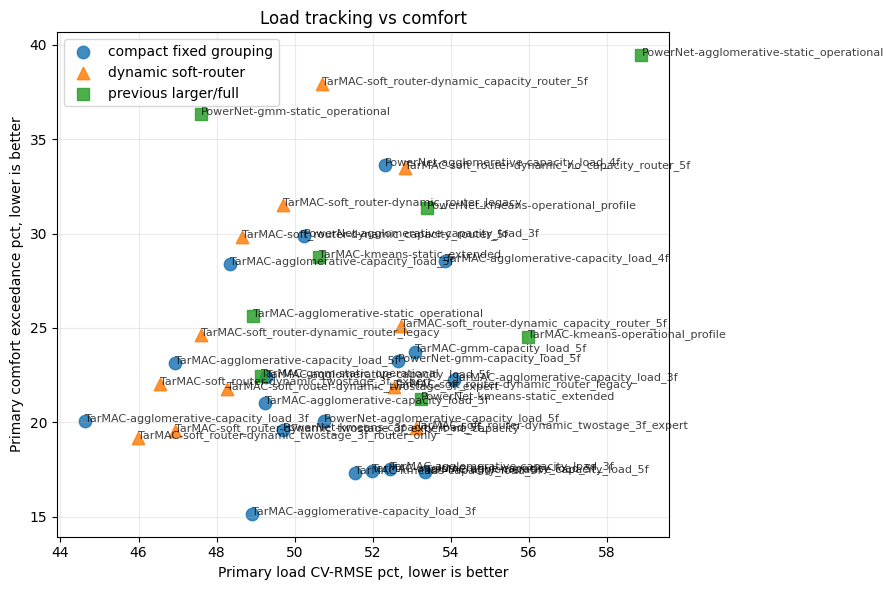

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
marker_map = {
    "compact fixed grouping": "o",
    "previous larger/full": "s",
    "dynamic soft-router": "^",
}

for feature_group, group_df in df.groupby("feature_group"):
    marker = marker_map.get(feature_group, "x")
    ax.scatter(
        group_df["primary_load_cv_rmse_pct"],
        group_df["primary_comfort_exceedance_pct"],
        label=feature_group,
        marker=marker,
        s=80,
        alpha=0.85,
    )

for _, row in df.iterrows():
    arch = str(row.get("architecture", "exp")).split()[0]
    method = row.get("grouping_method_short", "")
    features = row.get("grouping_feature_set_short", "")
    label = f"{arch}-{method}-{features}"
    ax.annotate(
        label,
        (row["primary_load_cv_rmse_pct"], row["primary_comfort_exceedance_pct"]),
        fontsize=8,
        alpha=0.75,
    )

ax.set_xlabel("Primary load CV-RMSE pct, lower is better")
ax.set_ylabel("Primary comfort exceedance pct, lower is better")
ax.set_title("Load tracking vs comfort")
ax.grid(alpha=0.25)
ax.legend()
plt.tight_layout()
plt.show()